# 13장 실습 — 병렬 Leaky 뉴런을 필터로 쓰기

**Spiking Neural Networks 쿡북 with Python** · 13장 실습 노트북

선형 Leaky 뉴런이 곧 **저역통과 필터**임을 직접 확인한다. snnTorch의 병렬화된 `StateLeaky`로 임펄스 응답을 보고, 노이즈 신호를 매끄럽게 다듬는다.

### 학습 목표
- `StateLeaky`로 병렬 Leaky 필터를 만든다(`output=False`로 막전위 출력).
- 임펄스에 대한 단일·직렬 필터 응답을 관찰한다.
- 노이즈가 섞인 신호를 필터로 매끄럽게 만든다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 설치와 임포트

`StateLeaky`는 선형 Leaky 뉴런을 시퀀스 전체에 병렬로 적용한다.

In [1]:
import torch
import snntorch as snn
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0)

## 2. 필터 층과 입력 신호 만들기

감쇠율 `beta`가 평활(smoothing) 강도를 정한다. 두 개의 필터 층을 만들어 직렬로 쌓을 준비를 한다. 입력은 (1) 한 번만 1인 **임펄스**와 (2) **가우시안 노이즈** 두 가지다. 형태는 (시간, 배치, 채널)이다.

In [3]:
TIMESTEPS = 600
BETA = 0.9    

layer1 = snn.RLeaky(beta=BETA, linear_features=1, output=False)

In [4]:
layer1 = snn.Leaky(beta=BETA, threshold=1e9, reset_mechanism='none')   # 순수 누설적분
layer2 = snn.Leaky(beta=BETA, threshold=1e9, reset_mechanism='none')

입력 형태 (시간, 배치, 채널): (600, 1, 1)
임펄스 응답 앞부분: [1.0, 0.9, 0.81, 0.729, 0.6561, 0.5905]


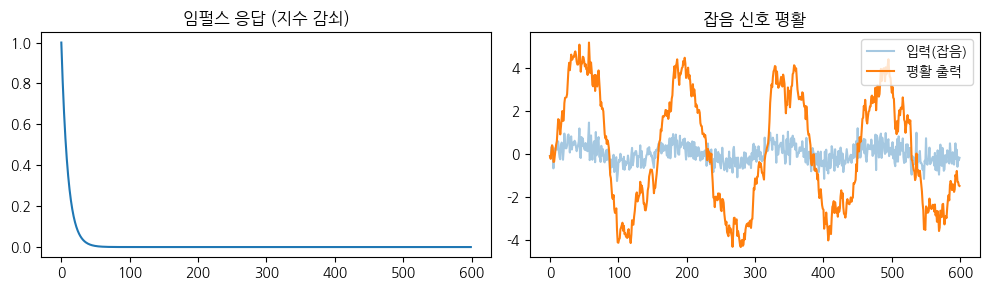

In [7]:
def run_filter(layer, x):
    mem = layer.init_leaky()           # 상태 초기화
    out = []
    for step in range(x.size(0)):
        spk, mem = layer(x[step], mem) # 두 번째 반환값이 막전위
        out.append(mem.squeeze())
    return torch.stack(out)


# (1) 임펄스: t=0에서만 1
impulse = torch.zeros(TIMESTEPS, 1, 1)
impulse[0, 0, 0] = 1.0

# (2) 노이즈: 사인파 + 가우시안 잡음
t = torch.linspace(0, 8 * 3.14159, TIMESTEPS)
noisy = (torch.sin(t) * 0.4 + torch.randn(TIMESTEPS) * 0.35).view(TIMESTEPS, 1, 1)

print('입력 형태 (시간, 배치, 채널):', tuple(impulse.shape))

imp_resp = run_filter(layer1, impulse)
noisy_resp = run_filter(layer2, noisy)
print('임펄스 응답 앞부분:', [round(v, 4) for v in imp_resp[:6].tolist()])

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(imp_resp.detach()); axs[0].set_title('임펄스 응답 (지수 감쇠)')
axs[1].plot(noisy.squeeze(), alpha=0.4, label='입력(잡음)')
axs[1].plot(noisy_resp.detach(), label='평활 출력')
axs[1].legend(); axs[1].set_title('잡음 신호 평활')
plt.tight_layout(); plt.show()

## 3. 단일 필터의 임펄스 응답

임펄스를 한 필터에 통과시키면, 막전위가 솟았다 지수적으로 감쇠하는 응답이 나온다 — 전형적인 저역통과 필터의 모습이다.

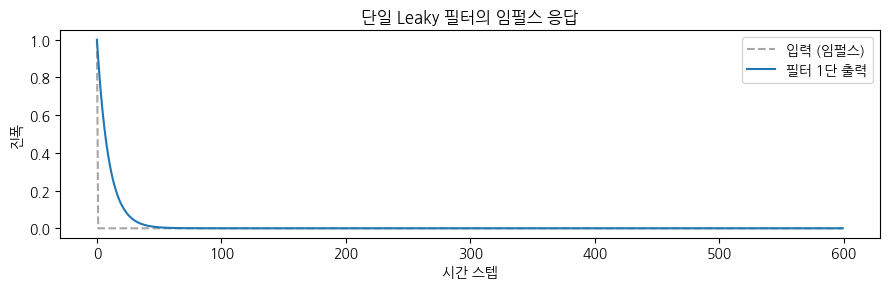

In [9]:
out1 = run_filter(layer1, impulse)        # (시간,) 막전위 시퀀스

plt.figure(figsize=(9, 3))
plt.plot(impulse[:, 0, 0], '--', color='gray', alpha=0.7, label='입력 (임펄스)')
plt.plot(out1.detach(), color='tab:blue', label='필터 1단 출력')
plt.xlabel('시간 스텝'); plt.ylabel('진폭')
plt.title('단일 Leaky 필터의 임펄스 응답'); plt.legend(); plt.tight_layout(); plt.show()

## 4. 직렬(2단) 필터 응답

첫 필터의 출력을 두 번째 필터에 다시 통과시키면 응답이 더 매끄러워진다. 필터를 쌓을수록 평활 효과가 커진다.

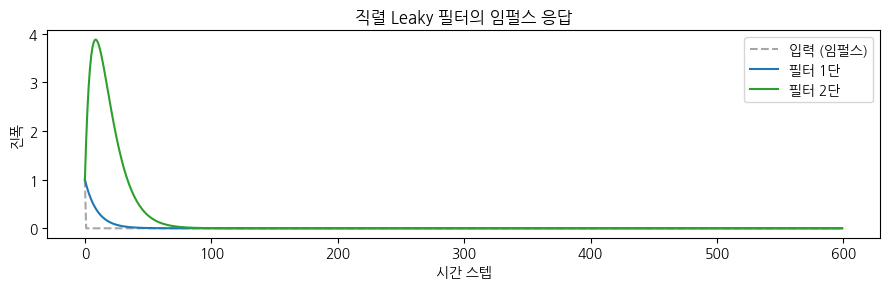

In [12]:
out1 = run_filter(layer1, impulse)            # (시간,) 1단 막전위
out2 = run_filter(layer2, out1.view(-1, 1, 1))  # 1단 출력을 2단에 통과 → (시간,)

plt.figure(figsize=(9, 3))
plt.plot(impulse[:, 0, 0], '--', color='gray', alpha=0.7, label='입력 (임펄스)')
plt.plot(out1.detach(), color='tab:blue', label='필터 1단')
plt.plot(out2.detach(), color='tab:green', label='필터 2단')
plt.xlabel('시간 스텝'); plt.ylabel('진폭')
plt.title('직렬 Leaky 필터의 임펄스 응답'); plt.legend(); plt.tight_layout(); plt.show()

## 5. 노이즈 신호 다듬기

잡음이 섞인 신호를 필터에 통과시키면 고주파 잡음이 깎이고 부드러운 추세가 남는다. Leaky 뉴런을 **신호 필터**로 쓰는 예다.

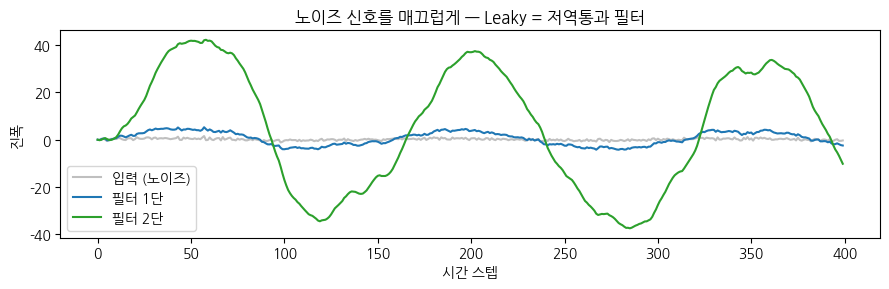

In [14]:
n1 = run_filter(layer1, noisy)              # (시간,) 1단 평활
n2 = run_filter(layer2, n1.view(-1, 1, 1))  # 1단 출력을 2단에 통과 → (시간,)

seg = slice(0, 400)
plt.figure(figsize=(9, 3))
plt.plot(noisy[seg, 0, 0], color='gray', alpha=0.5, label='입력 (노이즈)')
plt.plot(n1.detach()[seg], color='tab:blue', label='필터 1단')
plt.plot(n2.detach()[seg], color='tab:green', label='필터 2단')
plt.xlabel('시간 스텝'); plt.ylabel('진폭')
plt.title('노이즈 신호를 매끄럽게 — Leaky = 저역통과 필터'); plt.legend(); plt.tight_layout(); plt.show()

## 정리

- `StateLeaky(output=False)`는 선형 Leaky 뉴런의 막전위를 시퀀스 전체에 병렬로 계산한다.
- 임펄스 응답은 지수 감쇠 형태이며, 필터를 쌓을수록 더 부드러워진다.
- Leaky 뉴런은 저역통과 필터로, 노이즈 신호를 다듬는 데 쓸 수 있다.

마지막 14장에서는 이진화·델타·Forward-Forward·NIR 같은 심화 주제를 짧은 레시피로 둘러본다.